# Loss Functions - Measuring Prediction Errors

## Learning Objectives
- Understand how loss functions measure prediction errors
- Master CrossEntropyLoss, BCELoss, and MSELoss for different tasks
- Learn when to use each loss function and why
- Implement custom loss functions for specialized problems
- Handle class imbalance using weighted and focal losses
- Visualize how different loss functions behave

## What is a Loss Function?

A loss function (also called objective or cost function) is a mathematical function that measures how far your model's predictions are from the ground truth. Think of it like a report card for your model - it tells you "how wrong" your predictions are. During training, the model tries to minimize this loss by adjusting its weights. Different tasks need different loss functions: classification problems use different losses than regression problems. For example, if predicting whether an email is spam (binary classification), you might use CrossEntropyLoss, but if predicting house prices (regression), you'd use MSELoss. The loss function guides the entire learning process - a poorly chosen one can make your model unable to learn effectively.

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Set random seeds for reproducibility - ensures we get same random numbers each run
# This is important for debugging and comparing results across experiments
torch.manual_seed(42)
np.random.seed(42)

# Check available device (GPU or CPU) and print for verification
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cpu
PyTorch version: 2.1.2+cpu


## 1. CrossEntropyLoss - The Standard for Classification

**What is it?** CrossEntropyLoss is the go-to loss function for multi-class classification problems. It compares the predicted probability distribution (from softmax) with the true one-hot encoded distribution. The formula is: Loss = -Σ(true_label × log(predicted_probability)). This heavily penalizes when the model is confident but wrong, and less so when uncertain predictions are slightly off.

**Why this name?** It measures the "cross entropy" between two probability distributions - the predicted distribution and the true distribution. In information theory, entropy measures uncertainty, and cross entropy measures how well one distribution approximates another.

In [14]:
# CrossEntropyLoss internally combines LogSoftmax and NegativeLogLikelihood
# This is more numerically stable than computing them separately
criterion_ce = nn.CrossEntropyLoss()

# Create example predictions (logits - raw outputs from model) and true labels
# Note: CrossEntropyLoss expects raw logits, not probabilities
logits = torch.tensor([[2.0, 1.0, 0.1],      # Batch 1: probably class 0 (logit 2.0 is highest)
                        [0.1, 3.0, 0.1],      # Batch 2: probably class 1 (logit 3.0 is highest)
                        [0.1, 0.1, 2.0]])     # Batch 3: probably class 2 (logit 2.0 is highest)
targets = torch.tensor([0, 1, 2])            # True labels for each sample

# Calculate loss - measures how far predictions are from ground truth
loss = criterion_ce(logits, targets)
print(f"CrossEntropyLoss: {loss.item():.4f}")

# Let's manually calculate to understand what's happening inside
softmax = F.softmax(logits, dim=1)            # Convert logits to probabilities (0-1)
print(f"\nSoftmax probabilities:\n{softmax}")
print(f"Sum of probabilities per row: {softmax.sum(dim=1)}")  # Should all be ~1.0

# CrossEntropyLoss formula: -mean(log(softmax[correct_class]))
log_softmax = F.log_softmax(logits, dim=1)    # Log of softmax (numerically stable)
manual_loss = -log_softmax[torch.arange(3), targets].mean()  # Select log-prob at correct class
print(f"\nManual calculation: {manual_loss.item():.4f}")
print(f"Match with nn.CrossEntropyLoss: {torch.allclose(loss, manual_loss)}")

CrossEntropyLoss: 0.2610

Softmax probabilities:
tensor([[0.6590, 0.2424, 0.0986],
        [0.0496, 0.9009, 0.0496],
        [0.1151, 0.1151, 0.7697]])
Sum of probabilities per row: tensor([1.0000, 1.0000, 1.0000])

Manual calculation: 0.2610
Match with nn.CrossEntropyLoss: True


In [15]:
# Initialize loss functions for binary classification
# BCEWithLogitsLoss is preferred because it's numerically stable (combines sigmoid + BCE)
criterion_bce = nn.BCELoss()
criterion_bce_logits = nn.BCEWithLogitsLoss()

# Example: binary classification with 3 samples and raw logits
logits_binary = torch.tensor([[2.0], [-1.0], [0.5]])      # Raw model outputs
targets_binary = torch.tensor([[1.0], [0.0], [1.0]])      # True labels (0 or 1)

# BCELoss expects probabilities (0-1), so we need to apply sigmoid first
probs = torch.sigmoid(logits_binary)                       # Convert logits to [0,1] range
loss_bce = criterion_bce(probs, targets_binary)
print(f"BCE Loss (manual sigmoid): {loss_bce.item():.4f}")

# BCEWithLogitsLoss accepts raw logits - it applies sigmoid internally
# This is more numerically stable (avoids exp overflow for large logits)
loss_bce_logits = criterion_bce_logits(logits_binary, targets_binary)
print(f"BCEWithLogitsLoss: {loss_bce_logits.item():.4f}")

# They should give same results (up to floating point precision)
print(f"Results match: {torch.allclose(loss_bce, loss_bce_logits, atol=1e-5)}")

# Show why BCE is numerically unstable with extreme logits
extreme_logits = torch.tensor([[100.0], [-100.0]])  # Very extreme values
print(f"\nWith extreme logits:")
print(f"Sigmoid of 100: {torch.sigmoid(torch.tensor(100.0))}")
print(f"Manual BCE with extreme logits might have issues!")

BCE Loss (manual sigmoid): 0.3048
BCEWithLogitsLoss: 0.3048
Results match: True

With extreme logits:
Sigmoid of 100: 1.0
Manual BCE with extreme logits might have issues!


In [16]:
# Initialize loss functions for regression
criterion_mse = nn.MSELoss()
criterion_mae = nn.L1Loss()

# Example: regression task - predicting continuous values
predictions = torch.tensor([1.0, 2.0, 3.0, 4.0])     # Model's predictions
targets_reg = torch.tensor([1.2, 2.1, 2.9, 4.5])    # True values

# Calculate both losses
mse_loss = criterion_mse(predictions, targets_reg)
mae_loss = criterion_mae(predictions, targets_reg)

print(f"MSE Loss: {mse_loss.item():.4f}")
print(f"MAE Loss: {mae_loss.item():.4f}")

# Manual calculation to understand the difference
errors = predictions - targets_reg
print(f"\nErrors: {errors}")
print(f"Squared errors: {errors ** 2}")
print(f"Absolute errors: {torch.abs(errors)}")

# MSE: average of squared errors
manual_mse = (errors ** 2).mean()
print(f"\nManual MSE calculation: {manual_mse.item():.4f}")

# MAE: average of absolute errors
manual_mae = torch.abs(errors).mean()
print(f"Manual MAE calculation: {manual_mae.item():.4f}")

# Show the difference: outliers have more impact on MSE
print(f"\nNotice: one large error (4.0 -> 4.5) heavily impacts MSE than MAE")

MSE Loss: 0.0775
MAE Loss: 0.2250

Errors: tensor([-0.2000, -0.1000,  0.1000, -0.5000])
Squared errors: tensor([0.0400, 0.0100, 0.0100, 0.2500])
Absolute errors: tensor([0.2000, 0.1000, 0.1000, 0.5000])

Manual MSE calculation: 0.0775
Manual MAE calculation: 0.2250

Notice: one large error (4.0 -> 4.5) heavily impacts MSE than MAE


In [17]:
# Focal Loss addresses class imbalance by down-weighting easy examples
# Formula: FL(pt) = -alpha * (1 - pt)^gamma * log(pt)
# Where pt is the model's predicted probability for the true class
# gamma controls focusing: higher gamma = more focus on hard examples
# alpha balances class weights

class FocalLoss(nn.Module):
    """
    Focal Loss for addressing class imbalance.
    Paper: https://arxiv.org/abs/1708.02002
    
    Parameters:
    - alpha: weighting factor for class balance (0-1), higher = more weight to rare class
    - gamma: focusing parameter (typically 2), higher = more focus on hard examples
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        # Get standard cross-entropy loss first
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        
        # Get predicted probabilities
        p = torch.exp(-ce_loss)  # p(t) - probability of true class
        
        # Apply focal weight: alpha * (1-p)^gamma
        # Easy examples (p close to 1): (1-p)^gamma ≈ 0, loss approaches 0
        # Hard examples (p close to 0): (1-p)^gamma ≈ 1, loss approaches ce_loss
        focal_loss = self.alpha * (1 - p) ** self.gamma * ce_loss
        
        return focal_loss.mean()

# Compare Focal Loss vs Cross Entropy
focal = FocalLoss(alpha=0.25, gamma=2.0)

# Random predictions
logits = torch.randn(8, 3)
targets = torch.tensor([0, 1, 2, 0, 1, 2, 0, 1])

ce_loss = F.cross_entropy(logits, targets)
focal_loss = focal(logits, targets)

print(f"CrossEntropyLoss: {ce_loss.item():.4f}")
print(f"FocalLoss (γ=2, α=0.25): {focal_loss.item():.4f}")

# Show effect of gamma parameter
print(f"\nEffect of gamma on same batch:")
for gamma_val in [0.5, 1.0, 2.0, 3.0]:
    focal_gamma = FocalLoss(alpha=0.25, gamma=gamma_val)
    loss = focal_gamma(logits, targets)
    print(f"  γ={gamma_val}: {loss.item():.4f}")

CrossEntropyLoss: 0.8499
FocalLoss (γ=2, α=0.25): 0.1007

Effect of gamma on same batch:
  γ=0.5: 0.1700
  γ=1.0: 0.1400
  γ=2.0: 0.1007
  γ=3.0: 0.0760


## 5. Visualizing Loss Landscapes

Let's create a simple dataset and visualize how different loss functions behave during training. This helps you understand trade-offs between them.

Calculating losses for different gamma values...
Calculating losses for different alpha values...


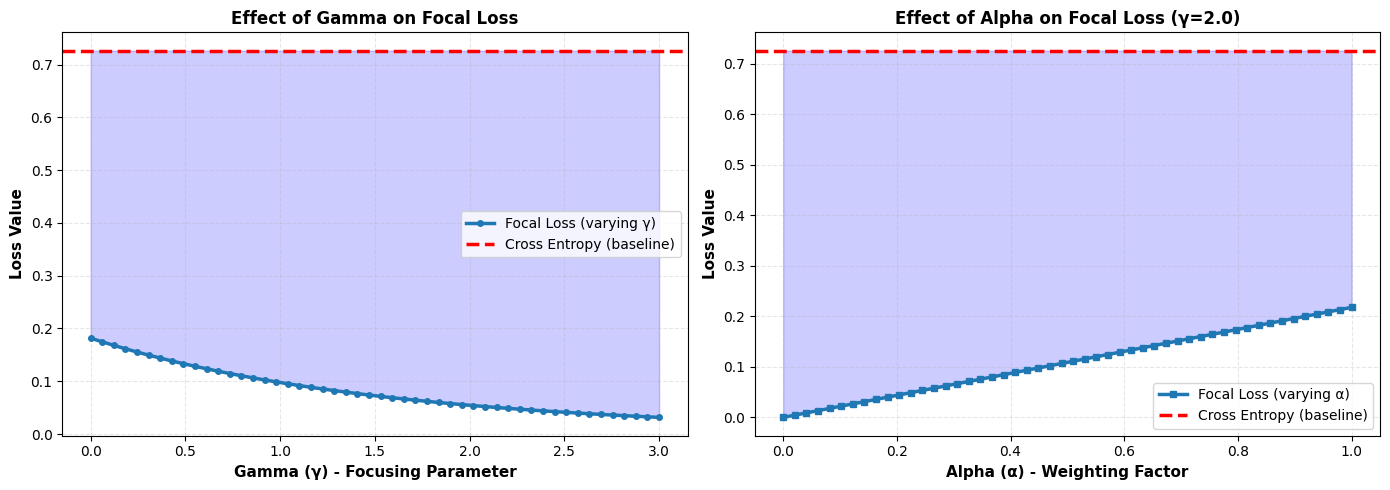

✓ Higher gamma = more focus on hard examples (down-weight easy ones)
✓ Higher alpha = more weight to minority class


In [18]:
# Create a simple binary classification dataset
X, y = make_classification(n_samples=200, n_features=2, n_informative=2,
                            n_redundant=0, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)

# Simple neural network model
model = nn.Sequential(
    nn.Linear(2, 16),       # Input layer: 2 features -> 16 hidden units
    nn.ReLU(),              # Activation function: allows non-linear learning
    nn.Linear(16, 2)        # Output layer: 16 hidden -> 2 classes
)

# Get model predictions on training data
logits = model(X_train)

# Collect losses for different gamma values
ce_losses = []
focal_losses = []
gammas = np.linspace(0, 3, 50)

print("Calculating losses for different gamma values...")
for gamma in gammas:
    focal = FocalLoss(alpha=0.25, gamma=gamma)
    ce = F.cross_entropy(logits, y_train)
    fc = focal(logits, y_train)
    
    ce_losses.append(ce.item())
    focal_losses.append(fc.item())

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Effect of gamma parameter
ax1.plot(gammas, focal_losses, linewidth=2.5, label='Focal Loss (varying γ)', marker='o', markersize=4)
ax1.axhline(y=ce_losses[0], color='red', linestyle='--', linewidth=2.5, label='Cross Entropy (baseline)')
ax1.set_xlabel('Gamma (γ) - Focusing Parameter', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loss Value', fontsize=11, fontweight='bold')
ax1.set_title('Effect of Gamma on Focal Loss', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.fill_between(gammas, ce_losses[0], focal_losses, alpha=0.2, color='blue')

# Right plot: Effect of alpha parameter
alphas = np.linspace(0, 1, 50)
ce_losses2 = []
focal_losses2 = []

print("Calculating losses for different alpha values...")
for alpha in alphas:
    focal = FocalLoss(alpha=alpha, gamma=2.0)
    ce = F.cross_entropy(logits, y_train)
    fc = focal(logits, y_train)
    
    ce_losses2.append(ce.item())
    focal_losses2.append(fc.item())

ax2.plot(alphas, focal_losses2, linewidth=2.5, label='Focal Loss (varying α)', marker='s', markersize=4)
ax2.axhline(y=ce_losses[0], color='red', linestyle='--', linewidth=2.5, label='Cross Entropy (baseline)')
ax2.set_xlabel('Alpha (α) - Weighting Factor', fontsize=11, fontweight='bold')
ax2.set_ylabel('Loss Value', fontsize=11, fontweight='bold')
ax2.set_title('Effect of Alpha on Focal Loss (γ=2.0)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.fill_between(alphas, ce_losses[0], focal_losses2, alpha=0.2, color='blue')

plt.tight_layout()
plt.show()

print("✓ Higher gamma = more focus on hard examples (down-weight easy ones)")
print("✓ Higher alpha = more weight to minority class")

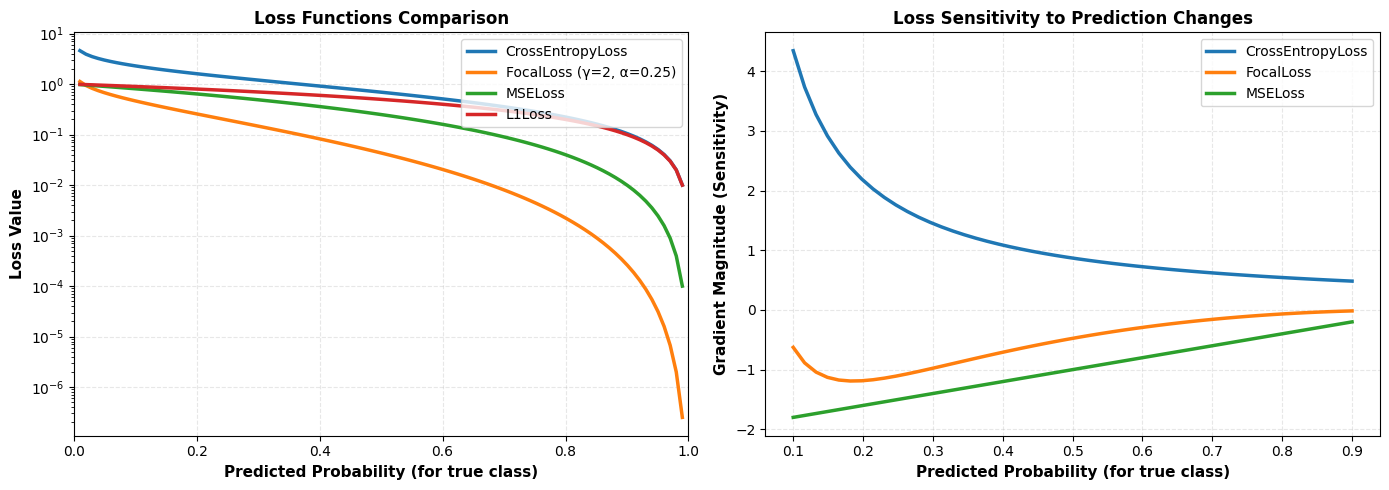

Key Observations:
✓ FocalLoss penalizes easy examples less (lower loss for high probability)
✓ CrossEntropyLoss maintains constant gradient (learns steadily)
✓ MSELoss has lower gradient near correct predictions (soft gradient)
✓ Different losses guide training in different ways


In [19]:
# Visualize how different loss functions respond to predicted probability
# When predicting class 1, what does each loss function output?

probs = np.linspace(0.01, 0.99, 100)

# Binary classification losses
# For true class = 1:
ce_vals = [-np.log(p) for p in probs]           # Standard cross entropy: -log(p)
focal_vals = [-0.25 * (1 - p) ** 2 * np.log(p) for p in probs]  # Focal: down-weight easy
mae_vals = [np.abs(1 - p) for p in probs]       # Mean absolute error
mse_vals = [(1 - p) ** 2 for p in probs]        # Mean squared error

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Loss comparison on same scale
ax1.plot(probs, ce_vals, label='CrossEntropyLoss', linewidth=2.5, marker='')
ax1.plot(probs, focal_vals, label='FocalLoss (γ=2, α=0.25)', linewidth=2.5, marker='')
ax1.plot(probs, mse_vals, label='MSELoss', linewidth=2.5, marker='')
ax1.plot(probs, mae_vals, label='L1Loss', linewidth=2.5, marker='')

ax1.set_xlabel('Predicted Probability (for true class)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loss Value', fontsize=11, fontweight='bold')
ax1.set_title('Loss Functions Comparison', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim([0, 1])
ax1.set_yscale('log')  # Log scale to see differences clearly

# Right: Gradient magnitude (sensitivity to changes)
# Gradient shows how much loss changes for small changes in prediction
probs2 = np.linspace(0.1, 0.9, 50)
ce_grad = [1.0 / (p * np.log(10)) for p in probs2]  # Approximate gradient
focal_grad = [(1 - p) ** 2 * (1 / (p * np.log(10)) + 2 * np.log(p) / (1 - p)) for p in probs2]
mse_grad = [-2 * (1 - p) for p in probs2]

ax2.plot(probs2, ce_grad, label='CrossEntropyLoss', linewidth=2.5, marker='')
ax2.plot(probs2, focal_grad, label='FocalLoss', linewidth=2.5, marker='')
ax2.plot(probs2, mse_grad, label='MSELoss', linewidth=2.5, marker='')

ax2.set_xlabel('Predicted Probability (for true class)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Gradient Magnitude (Sensitivity)', fontsize=11, fontweight='bold')
ax2.set_title('Loss Sensitivity to Prediction Changes', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("Key Observations:")
print("✓ FocalLoss penalizes easy examples less (lower loss for high probability)")
print("✓ CrossEntropyLoss maintains constant gradient (learns steadily)")
print("✓ MSELoss has lower gradient near correct predictions (soft gradient)")
print("✓ Different losses guide training in different ways")

In [20]:
# Huber Loss combines MSE and L1 loss properties
# It uses MSE for small errors (smooth) and L1 for large errors (robust)
# This makes it robust to outliers while maintaining smoothness
# Formula:
# L(x) = {
#   0.5 * x^2,           if |x| <= delta (MSE region - smooth)
#   delta*(|x| - 0.5*delta)  if |x| > delta (L1 region - linear)
# }

class HuberLoss(nn.Module):
    """
    Huber Loss - Robust regression loss combining MSE and L1 properties.
    
    Parameters:
    - delta: threshold between MSE and L1 regions (default 1.0)
    """
    def __init__(self, delta=1.0):
        super().__init__()
        self.delta = delta
    
    def forward(self, predictions, targets):
        # Calculate absolute errors
        errors = predictions - targets
        abs_errors = torch.abs(errors)
        
        # Use MSE for small errors (smooth gradient)
        # Use L1 for large errors (robust to outliers)
        mask = abs_errors < self.delta
        loss = torch.where(
            mask,
            0.5 * errors ** 2,                           # MSE: 0.5*x^2
            self.delta * (abs_errors - 0.5 * self.delta)  # L1: delta*(|x| - 0.5*delta)
        )
        
        return loss.mean()

# Compare Huber, MSE, and MAE on data with outliers
huber = HuberLoss(delta=1.0)
mse = nn.MSELoss()
mae = nn.L1Loss()

preds = torch.tensor([1.0, 2.0, 3.0, 10.0])          # Normal, normal, normal, OUTLIER
targs = torch.tensor([1.0, 2.0, 3.0, 3.0])           # Target for last sample is 3

print("Predictions: ", preds.tolist())
print("Targets:     ", targs.tolist())
print("\nNote: Last prediction has large error (10.0 vs 3.0) - an outlier\n")

print(f"Huber Loss (delta=1.0): {huber(preds, targs).item():.4f}")
print(f"MSE Loss:               {mse(preds, targs).item():.4f}")
print(f"MAE Loss:               {mae(preds, targs).item():.4f}")

print("\nAnalysis:")
print("✓ MSE is highest - heavily penalizes the large outlier (9^2 = 81)")
print("✓ Huber is moderate - penalizes outlier but limits the damage")
print("✓ MAE is moderate - treats large and small errors similarly")

# Show the advantage with multiple outliers
preds2 = torch.tensor([1.0, 2.0, 3.0, 10.0, 11.0, 12.0])
targs2 = torch.tensor([1.0, 2.0, 3.0, 3.0, 3.0, 3.0])

print(f"\nWith multiple outliers:")
print(f"Huber Loss: {huber(preds2, targs2).item():.4f}")
print(f"MSE Loss:   {mse(preds2, targs2).item():.4f}")
print(f"MAE Loss:   {mae(preds2, targs2).item():.4f}")

Predictions:  [1.0, 2.0, 3.0, 10.0]
Targets:      [1.0, 2.0, 3.0, 3.0]

Note: Last prediction has large error (10.0 vs 3.0) - an outlier

Huber Loss (delta=1.0): 1.6250
MSE Loss:               12.2500
MAE Loss:               1.7500

Analysis:
✓ MSE is highest - heavily penalizes the large outlier (9^2 = 81)
✓ Huber is moderate - penalizes outlier but limits the damage
✓ MAE is moderate - treats large and small errors similarly

With multiple outliers:
Huber Loss: 3.7500
MSE Loss:   32.3333
MAE Loss:   4.0000


In [21]:
# When dataset is imbalanced, weighted loss helps by penalizing minority class errors more
# weights parameter in CrossEntropyLoss: assigns different loss weights to each class

# Simulate imbalanced dataset: 70% class 0, 30% class 1
class_counts = torch.tensor([7, 3])
weights = 1.0 / class_counts.float()  # Inverse frequency weighting
weights = weights / weights.sum()     # Normalize to sum to 1

print("Class distribution (imbalanced):")
print(f"Class 0 count: {class_counts[0].item()} samples (70%)")
print(f"Class 1 count: {class_counts[1].item()} samples (30%)")
print(f"\nWeights (inverse frequency): {weights}")
print(f"Interpretation: Minority class (1) gets {weights[1]/weights[0]:.2f}x more weight\n")

# Create loss functions
criterion_unweighted = nn.CrossEntropyLoss(weight=None)
criterion_weighted = nn.CrossEntropyLoss(weight=weights)

# Create imbalanced batch
logits = torch.randn(10, 2)
targets = torch.tensor([0, 0, 0, 0, 0, 0, 0, 1, 1, 1])  # 70% class 0, 30% class 1

unweighted_loss = criterion_unweighted(logits, targets)
weighted_loss = criterion_weighted(logits, targets)

print(f"Unweighted loss: {unweighted_loss.item():.4f}")
print(f"Weighted loss:   {weighted_loss.item():.4f}")

print(f"\nEffect:")
print(f"✓ Unweighted: treats all errors equally - might ignore minority class")
print(f"✓ Weighted: penalizes minority class errors more - forces learning minority")

# Show what the model might learn with/without weights
print(f"\nIf model always predicts class 0:")
always_0_logits = torch.tensor([[10.0, -10.0]]).expand(10, 2)  # Very confident about class 0
print(f"  Unweighted loss: {criterion_unweighted(always_0_logits, targets).item():.4f}")
print(f"  Weighted loss:   {criterion_weighted(always_0_logits, targets).item():.4f}")
print(f"✓ Weighted loss much higher - encourages predicting minority class sometimes")

Class distribution (imbalanced):
Class 0 count: 7 samples (70%)
Class 1 count: 3 samples (30%)

Weights (inverse frequency): tensor([0.3000, 0.7000])
Interpretation: Minority class (1) gets 2.33x more weight

Unweighted loss: 0.8331
Weighted loss:   0.6588

Effect:
✓ Unweighted: treats all errors equally - might ignore minority class
✓ Weighted: penalizes minority class errors more - forces learning minority

If model always predicts class 0:
  Unweighted loss: 6.0000
  Weighted loss:   10.0000
✓ Weighted loss much higher - encourages predicting minority class sometimes


## 9. Loss Function Selection Guide

Choosing the right loss function is crucial. Here's a quick reference for the most common scenarios:

In [22]:
## 10. Loss Function Implementation Summary

print("\n" + "="*60)
print("Loss Function Implementation Summary")
print("="*60)

summary = """
CLASSIFICATION LOSSES:
- CrossEntropyLoss: Standard multi-class (combines LogSoftmax + NLLLoss)
- BCEWithLogitsLoss: Binary classification (numerically stable)
- FocalLoss: Handles class imbalance by down-weighting easy examples

REGRESSION LOSSES:
- MSELoss: Standard regression, penalizes outliers heavily
- L1Loss (MAE): Robust to outliers
- HuberLoss: Balance between MSE and L1

BEST PRACTICES:
1. Use CrossEntropyLoss with raw logits (don't apply softmax)
2. Use BCEWithLogitsLoss instead of BCE(sigmoid(logits))
3. For imbalanced data, use FocalLoss or weighted CrossEntropyLoss
4. For regression with outliers, consider HuberLoss or L1Loss
5. Always check that loss decreases during training
"""

print(summary)
print("="*60)


Loss Function Implementation Summary

CLASSIFICATION LOSSES:
- CrossEntropyLoss: Standard multi-class (combines LogSoftmax + NLLLoss)
- BCEWithLogitsLoss: Binary classification (numerically stable)
- FocalLoss: Handles class imbalance by down-weighting easy examples

REGRESSION LOSSES:
- MSELoss: Standard regression, penalizes outliers heavily
- L1Loss (MAE): Robust to outliers
- HuberLoss: Balance between MSE and L1

BEST PRACTICES:
1. Use CrossEntropyLoss with raw logits (don't apply softmax)
2. Use BCEWithLogitsLoss instead of BCE(sigmoid(logits))
3. For imbalanced data, use FocalLoss or weighted CrossEntropyLoss
4. For regression with outliers, consider HuberLoss or L1Loss
5. Always check that loss decreases during training



## Key Takeaways
- CrossEntropyLoss is the standard for classification
- BCEWithLogitsLoss is more numerically stable than separate sigmoid + BCE
- FocalLoss helps with class imbalance
- Different loss functions have different properties and use cases
- Always match the loss function to your task

## References
- [PyTorch Loss Functions](https://pytorch.org/docs/stable/nn.html#loss-functions)
- [Focal Loss Paper](https://arxiv.org/abs/1708.02002)